In [1]:
!pip install statsmodels


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import math  # Mathematical operations 
import scipy.stats as st  # Statistical calculations (e.g., confidence intervals)
from sklearn.preprocessing import MinMaxScaler  # Normalizing data to a specific range (e.g., [0,1])
import statsmodels.stats.api as sms
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu, \
    pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import statsmodels.graphics.gofplots as smg

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 500)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [3]:
df_control = pd.read_excel("/kaggle/input/ab-testing/ab_testing.xlsx", sheet_name="Control Group")


In [4]:
df_test = pd.read_excel("/kaggle/input/ab-testing/ab_testing.xlsx", sheet_name = "Test Group")

In [5]:
df_control.shape

(40, 4)

In [6]:
df_control.head()

,Impression,Click,Purchase,Earning
0,82529.45927,6090.07732,665.21125,2311.27714
1,98050.45193,3382.86179,315.08489,1742.80686
2,82696.02355,4167.96575,458.08374,1797.82745
3,109914.40040,4910.88224,487.09077,1696.22918
4,108457.76263,5987.65581,441.03405,1543.72018


In [7]:
df_control.describe().T

,count,mean,std,min,25%,50%,75%,max
Impression,40.00000,101711.44907,20302.15786,45475.94296,85726.69035,99790.70108,115212.81654,147539.33633
Click,40.00000,5100.65737,1329.98550,2189.75316,4124.30413,5001.22060,5923.80360,7959.12507
Purchase,40.00000,550.89406,134.10820,267.02894,470.09553,531.20631,637.95709,801.79502
Earning,40.00000,1908.56830,302.91778,1253.98952,1685.84720,1975.16052,2119.80278,2497.29522


In [8]:
df_control.isnull().any()

Impression    False
Click         False
Purchase      False
Earning       False
dtype: bool

In [9]:
df_test.shape

(40, 4)

In [10]:
df_test.head()

,Impression,Click,Purchase,Earning
0,120103.50380,3216.54796,702.16035,1939.61124
1,134775.94336,3635.08242,834.05429,2929.40582
2,107806.62079,3057.14356,422.93426,2526.24488
3,116445.27553,4650.47391,429.03353,2281.42857
4,145082.51684,5201.38772,749.86044,2781.69752


In [11]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Impression,40.00000,120512.41176,18807.44871,79033.83492,112691.97077,119291.30077,132050.57893,158605.92048
Click,40.00000,3967.54976,923.09507,1836.62986,3376.81902,3931.35980,4660.49791,6019.69508
Purchase,40.00000,582.10610,161.15251,311.62952,444.62683,551.35573,699.86236,889.91046
Earning,40.00000,2514.89073,282.73085,1939.61124,2280.53743,2544.66611,2761.54540,3171.48971


In [12]:
df_test.isnull().any()

Impression    False
Click         False
Purchase      False
Earning       False
dtype: bool

In [13]:
df = pd.concat([df_control, df_test],  ignore_index=True)

<h1 style="color:#1F2937; border-bottom:3px solid #5B7DB1; padding-bottom:8px;">
A/B Testi Hipotezleri
</h1>

<p style="color:#6B7280; font-size:16px;">
Bu analizde iki farklı teklif türünün satın alma performansı karşılaştırılmaktadır.
</p>

<div style="background-color:#F3F6FA; border-left:5px solid #5B7DB1; padding:14px 18px; margin:12px 0; border-radius:6px;">

<b style="color:#355C8A;">H₀ — Null Hipotezi</b>

<p>
“Average Bidding” ve “Maximum Bidding” teklif türlerinin
ortalama satın alma miktarları arasında fark yoktur.
</p>

</div>

<div style="background-color:#EFF5F1; border-left:5px solid #6B8F71; padding:14px 18px; margin:12px 0; border-radius:6px;">

<b style="color:#4F7055;">H₁ — Alternatif Hipotez</b>

<p>
“Average Bidding” ve “Maximum Bidding” teklif türlerinin
ortalama satın alma miktarları arasında fark vardır.
</p>

</div>

In [14]:
df_control["Purchase"].mean()

550.8940587702316

In [15]:
df_test["Purchase"].mean()

582.1060966484675

Normallik varsayımını test etmek için, kontrol ve test grupları üzerinde Purchase değişkeni için ayrı ayrı normallik testi yapacağız. Bu testi gerçekleştirmek için genellikle Shapiro-Wilk testi kullanacağız.

İlk olarak, her iki grup için (kontrol ve test grupları) normallik testi uygulayacağız ve elde edeceğimiz p-değerlerine göre şu kararları vereceğiz:

* H₀: Normal dağılım varsayımı sağlanmaktadır.
* H₁: Normal dağılım varsayımı sağlanmamaktadır.
  
Elde edilen p-değeri 0.05'ten küçükse, H₀ hipotezini reddedeceğiz, yani normal dağılım varsayımının sağlanmadığını söyleyeceğiz. Eğer p-değeri 0.05'ten büyükse, H₀ hipotezini reddedemeyeceğiz ve normal dağılım varsayımının sağlandığını kabul edeceğiz.

Bu şekilde, her iki grup için normallik varsayımını kontrol ederek hipotez testi öncesinde gerekli varsayımın sağlanıp sağlanmadığını belirleyeceğiz.

*<span style="font-size:17px; color:#00BFFF;">Normallik Varsayımı</span>*

In [16]:
test_stat_control, pvalue_control = shapiro(df_control["Purchase"])

print(f'Kontrol Grubu için Shapiro-Wilk Testi: Stat={test_stat_control}, p-value={pvalue_control}')

Kontrol Grubu için Shapiro-Wilk Testi: Stat=0.9772692828452955, p-value=0.5891071186294093


In [17]:
# p-value < 0.05 ise veriler normal dağılmıyor demektir
if pvalue_control < 0.05:
    print("Kontrol grubunun verisi normal dağılmıyor.")
else:
    print("Kontrol grubunun verisi normal dağılıyor.")


Kontrol grubunun verisi normal dağılıyor.


In [18]:
# Q-Q grafiği oluşturma
# fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Kontrol Grubu Q-Q Grafiği
#smg.qqplot(df_control["Purchase"], line ='45', ax=axs[0])
#axs[0].set_title('Kontrol Grubu Q-Q Grafiği')

# Test Grubu Q-Q Grafiği
#smg.qqplot(df_test["Purchase"], line ='45', ax=axs[1])
#axs[1].set_title('Test Grubu Q-Q Grafiği')

# Grafikleri göster
#plt.tight_layout()
#plt.show()

In [19]:
test_stat_test, pvalue_test = shapiro(df_test["Purchase"])

print(f'Test Grubu için Shapiro-Wilk Testi: Stat={test_stat_test}, p-value={pvalue_test}')

Test Grubu için Shapiro-Wilk Testi: Stat=0.9589454139336723, p-value=0.15413405050730578


In [20]:
if pvalue_test < 0.05:
    print("Test grubunun verisi normal dağılmıyor.")
else:
    print("Normal dağılımdan sapmaya ilişkin yeterli kanıt bulunmamıştır.")

Normal dağılımdan sapmaya ilişkin yeterli kanıt bulunmamıştır.


> Varyans Homojenliği :

> * H₀: Varyanslar homojendir.
> * H₁: Varyanslar homojen Değildir.
> * p < 0.05 H₀ RED , p > 0.05 H₀ REDDEDİLEMEZ

> Kontrol ve test grubu için varyans homojenliğinin sağlanıp sağlanmadığını Purchase değişkeni üzerinden test edelim.


*<span style="font-size:17px; color:#00BFFF;">Varyans Homojenliği</span>*

In [21]:
test_stat, pvalue = levene(df_control["Purchase"], df_test["Purchase"])

print(f'Levene Testi: Stat={test_stat}, p-value={pvalue}')

# pvalue < 0.05 ise varyanslar homojen değil demektir
if pvalue < 0.05:
    print("Varyanslar homojen değil.")
else:
    print("Varyanslar homojen.")

Levene Testi: Stat=2.6392694728747363, p-value=0.10828588271874791
Varyanslar homojen.


> *Varsayımlar sağlandığından bağımsız iki örneklem t testi (parametrik test) kullanalım*

In [22]:
# Bağımsız iki örneklem t-testini uygulayalım
stat, p_value = ttest_ind(df_control["Purchase"], df_test["Purchase"])

# Sonuçları yazdırma
print(f't-Testi Sonuçları: Stat={stat}, p-value={p_value}')

# p-value < 0.05 ise gruplar arasında anlamlı bir fark vardır
if p_value < 0.05:
    print("Gruplar arasında anlamlı bir fark vardır.")
else:
    print("Gruplar arasında anlamlı bir fark yoktur.")

t-Testi Sonuçları: Stat=-0.9415584300312931, p-value=0.3493257920210858
Gruplar arasında anlamlı bir fark yoktur.


>  Bu durumda, gruplar arasında istatistiksel olarak anlamlı bir fark yoktur. 

In [23]:
control_corr = df_control.corr()

In [24]:
print("Kontrol Grubu Korelasyon Matrisi:")
print(control_corr)

Kontrol Grubu Korelasyon Matrisi:
            Impression    Click  Purchase  Earning
Impression     1.00000 -0.31149   0.21457  0.10705
Click         -0.31149  1.00000   0.05740 -0.35669
Purchase       0.21457  0.05740   1.00000  0.06173
Earning        0.10705 -0.35669   0.06173  1.00000


In [25]:
test_corr = df_test.corr()

In [26]:
print("Test Grubu Korelasyon Matrisi:")
print(test_corr)

Test Grubu Korelasyon Matrisi:
            Impression    Click  Purchase  Earning
Impression     1.00000 -0.20275   0.13780  0.10665
Click         -0.20275  1.00000  -0.07441  0.19778
Purchase       0.13780 -0.07441   1.00000  0.10248
Earning        0.10665  0.19778   0.10248  1.00000


Text(0.5, 1.0, 'Test Grubu Korelasyon Matrisi')

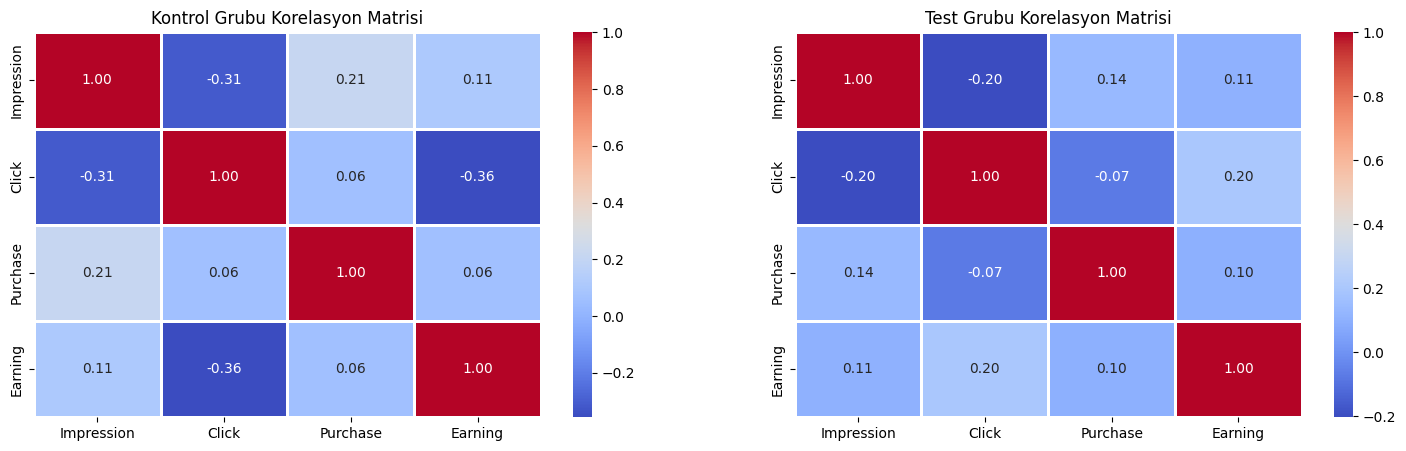

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

# Kontrol Grubu Korelasyon Isı Haritası

sns.heatmap(control_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.9, ax=ax[0])
ax[0].set_title('Kontrol Grubu Korelasyon Matrisi')


# Test Grubu Korelasyon Isı Haritası

sns.heatmap(test_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.9, ax=ax[1])
ax[1].set_title('Test Grubu Korelasyon Matrisi')



Hem kontrol grubunda hem de test grubunda Impression, Click ve Earning ile Purchase arasındaki doğrusal ilişkilerin zayıf kaldığı görülüyor. Bu korelasyonlar, bidding türü değişikliklerinin "*Purchase*" üzerindeki etkisini tek başına açıklamaz.

<h1 style="color:#1F2937; border-bottom:3px solid #5B7DB1; padding-bottom:8px;">
Satın Alma Dönüşüm Oranlarının Karşılaştırılması
</h1>

<p style="color:#6B7280; font-size:16px;">
Önceki bölümde ortalama satın alma miktarları karşılaştırıldı.
Bu bölümde ise tıklama başına satın alma (Purchase / Click)
ve gösterim başına satın alma (Purchase / Impression)
oranları ayrı ayrı incelenecektir.
</p>

<div style="background-color:#F3F6FA; border-left:5px solid #5B7DB1; padding:14px 18px; margin:12px 0; border-radius:6px;">
<b style="color:#355C8A;">H₀ — Null Hipotezi</b>
<p>
İncelenen oranın gözlem başına ortalaması,
“Average Bidding” ve “Maximum Bidding” gruplarında eşittir.
</p>
</div>

<div style="background-color:#EFF5F1; border-left:5px solid #6B8F71; padding:14px 18px; margin:12px 0; border-radius:6px;">
<b style="color:#4F7055;">H₁ — Alternatif Hipotez</b>
<p>
İncelenen oranın gözlem başına ortalaması,
“Average Bidding” ve “Maximum Bidding” gruplarında farklıdır.
</p>
</div>

<p style="color:#6B7280;">
Her oran için ayrı bir Welch t-testi uygulanacaktır.
Bu ek analizler keşif amaçlıdır.
</p>

In [28]:
# Kontrol grubu dönüşüm oranları
df_control["Purchase_Click_Rate"] = (
    df_control["Purchase"] / df_control["Click"]
)

df_control["Purchase_Impression_Rate"] = (
    df_control["Purchase"] / df_control["Impression"]
)

# Test grubu dönüşüm oranları
df_test["Purchase_Click_Rate"] = (
    df_test["Purchase"] / df_test["Click"]
)

df_test["Purchase_Impression_Rate"] = (
    df_test["Purchase"] / df_test["Impression"]
)


In [29]:
control_rate = df_control["Purchase_Click_Rate"]
test_rate = df_test["Purchase_Click_Rate"]

stat, p_value = ttest_ind(
    control_rate,
    test_rate,
    equal_var=False
)

print("Purchase / Click dönüşüm oranı")
print(f"Kontrol grubu ortalaması: {control_rate.mean():.2%}")
print(f"Test grubu ortalaması: {test_rate.mean():.2%}")
print(f"Welch t-testi p-değeri: {p_value:.4f}")

if p_value < 0.05:
    print("Gruplar arasında anlamlı bir fark vardır.")
else:
    print("Gruplar arasında anlamlı bir fark yoktur.")

Purchase / Click dönüşüm oranı
Kontrol grubu ortalaması: 11.59%
Test grubu ortalaması: 15.66%
Welch t-testi p-değeri: 0.0025
Gruplar arasında anlamlı bir fark vardır.


In [30]:
control_rate = df_control["Purchase_Impression_Rate"]
test_rate = df_test["Purchase_Impression_Rate"]

stat, p_value = ttest_ind(
    control_rate,
    test_rate,
    equal_var=False
)

print("Purchase / Impression dönüşüm oranı")
print(f"Kontrol grubu ortalaması: {control_rate.mean():.2%}")
print(f"Test grubu ortalaması: {test_rate.mean():.2%}")
print(f"Welch t-testi p-değeri: {p_value:.4f}")

if p_value < 0.05:
    print("Gruplar arasında anlamlı bir fark vardır.")
else:
    print("Gruplar arasında anlamlı bir fark yoktur.")

Purchase / Impression dönüşüm oranı
Kontrol grubu ortalaması: 0.56%
Test grubu ortalaması: 0.49%
Welch t-testi p-değeri: 0.0557
Gruplar arasında anlamlı bir fark yoktur.


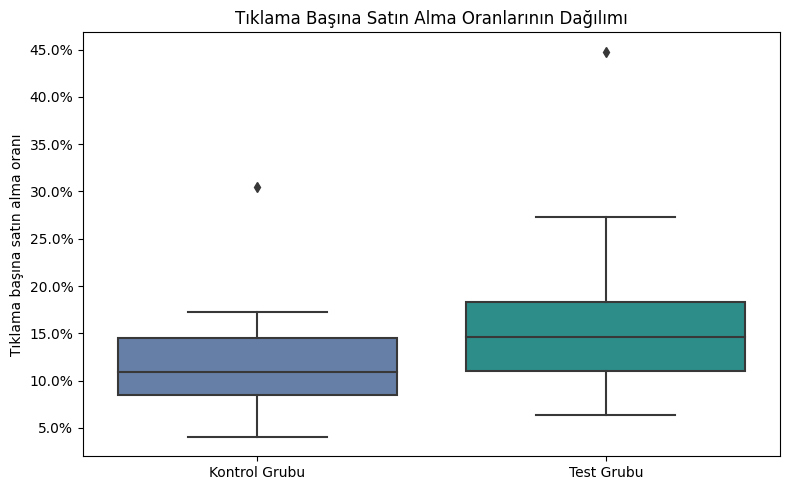

In [31]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=[
        df_control["Purchase_Click_Rate"],
        df_test["Purchase_Click_Rate"]
    ],
    palette=["#5B7DB1", "#1C9D98"]
)

plt.xticks([0, 1], ["Kontrol Grubu", "Test Grubu"])
plt.ylabel("Tıklama başına satın alma oranı")
plt.title("Tıklama Başına Satın Alma Oranlarının Dağılımı")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

Test grubu, ortalama satın alma miktarında anlamlı bir üstünlük göstermemiştir. Ancak Purchase/Click oranının test grubunda ortalaması anlamlı biçimde daha yüksektir (p ≈ 0.0025). Bu keşifsel bulgu, tıklama sonrası satın alma açısından test grubu lehine bir fark olduğunu göstermektedir. Diğer taraftan, gösterim başına satın alma oranında ise istatistiksel olarak anlamlı bir fark bulunmamıştır (p ≈ 0.0557).